# 7_Select_and_Zoom_Specific_Color_Areas

Autor: Jorge García Cevallos

En este notebook, aplicaremos los conceptos desarrollados en los capítulos 4, 5 y 6 para combinar la detección de un color específico con transformaciones geométricas como el zoom y el desplazamiento. El objetivo es identificar todas las áreas de la imagen que contengan un color particular, como el azul, y aplicar un zoom en cada una de estas áreas. Esta técnica nos permite enfocar y analizar con mayor precisión las regiones de interés que contienen el color seleccionado, facilitando el estudio detallado de cada objeto que cumpla con el criterio de color.

### Librerías

In [118]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import math
import os

### Función que muestra los detalles de la imagen. 

In [119]:
# Función para mostrar información básica sobre una imagen, incluyendo su tamaño, valor máximo y valor mínimo de píxeles.
# (Antigua función)
def howis(img):
  print('size = ',img.shape)
  print('max  = ',np.max(img))
  print('min  = ',np.min(img))

In [120]:
# Función para mostrar una imagen utilizando la biblioteca matplotlib.
def plot_show_image(imagen):
    imageRGB = imagen[:,:,[2,1,0]] 
    plt.imshow(imageRGB)
    plt.show()

In [121]:
# Función para aplicar una operación de dilatación a una imagen utilizando un kernel de tamaño definido.
def dilatar_imagen(imagen,tamaño):
    kernel = cv.getStructuringElement(cv.MORPH_RECT, (tamaño, tamaño))  # Define el kernel de dilatación
    img_dilatada = cv.dilate(imagen, kernel)
    return img_dilatada

In [122]:
# Función para aplicar una operación de erosión a una imagen utilizando un kernel de tamaño definido.
def ero_imagen(imagen,tamaño):
    kernel = cv.getStructuringElement(cv.MORPH_RECT, (tamaño, tamaño))  # Define el kernel de erosión
    img_erodida = cv.erode(imagen, kernel)
    return img_erodida

## Leer Imagen a color

In [123]:
ruta_imagen = os.path.join('..', 'Imagenes', 'Color', 'icosDriverMotor2.jpeg')
Icv = cv.imread(ruta_imagen)
howis(Icv)

size =  (1200, 1600, 3)
max  =  255
min  =  0


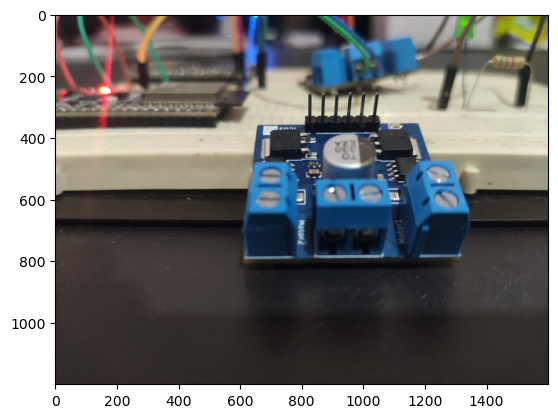

In [124]:
# Convertimos la imagen de BGR a RGB reordenando los canales.
plot_show_image(Icv)

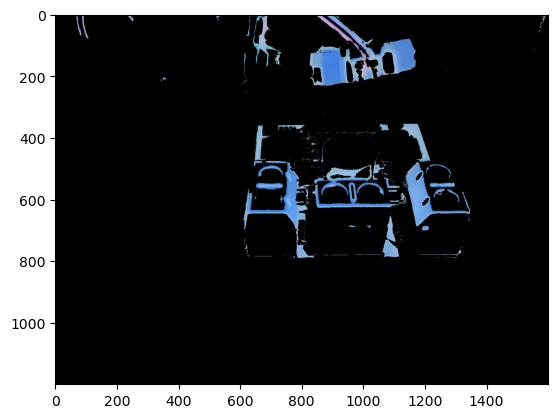

In [125]:
# Seleccionar el rango de color azul en el espacio BGR mediante ajuste manual.
rango_bajo_azul2 = np.array([50,65,0])  # Valor mínimo de B,G,R para el azul
rango_alto_azul2 = np.array([200, 135, 60])  # Valor máximo de B,G,R para el azul

# Crear una máscara de los píxeles que están en el rango de azul
mascara_azul2 = cv.inRange(Icv, rango_bajo_azul2, rango_alto_azul2)

# Aplicar la máscara a la imagen original
objeto_azul = cv.bitwise_and(Icv, Icv, mask=mascara_azul2)

plt.imshow(objeto_azul*255,cmap='gray')
plt.show()

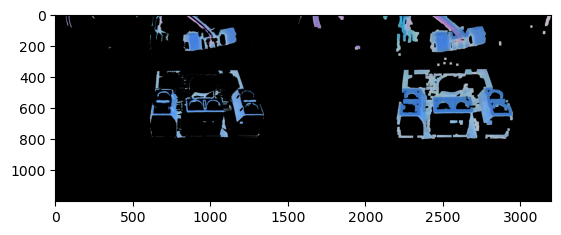

In [126]:
#Usamos dilatación para expandir y conectar regiones de interés, mejorando la detección y el análisis de características en la imagen.
img_dilatada=dilatar_imagen(objeto_azul,15)
img_juntas = np.concatenate((objeto_azul,img_dilatada),axis=1)

plt.imshow(img_juntas*255,cmap='gray')
plt.show()

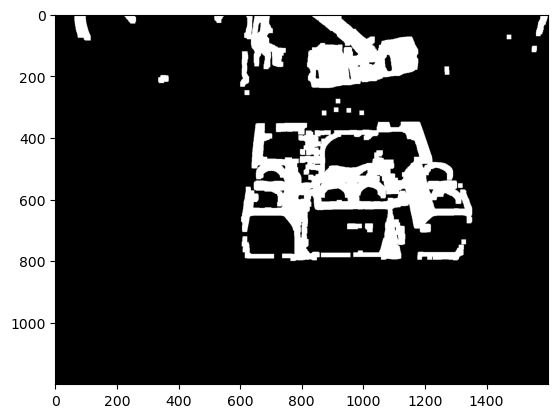

In [127]:
# Convertimos la imagen dilatada a escala de grises y aplicamos un umbral para obtener una máscara binaria, que resalta las áreas de interés en la imagen original.
gris_img = cv.cvtColor(img_dilatada, cv.COLOR_BGR2GRAY)
_, mascara = cv.threshold(gris_img, 0, 255, cv.THRESH_BINARY)
plt.imshow(mascara,cmap='gray')
plt.show()

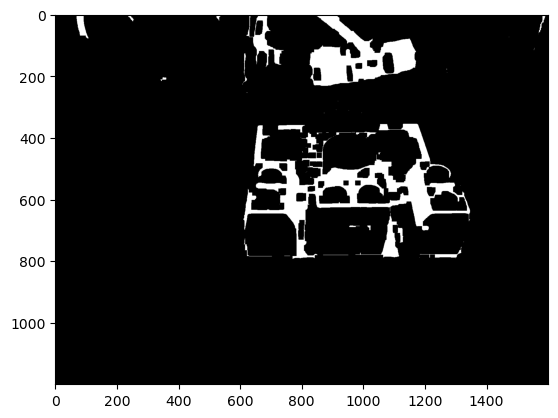

In [128]:
new_mask = ero_imagen(mascara,15)
plt.imshow(new_mask,cmap='gray')
plt.show()

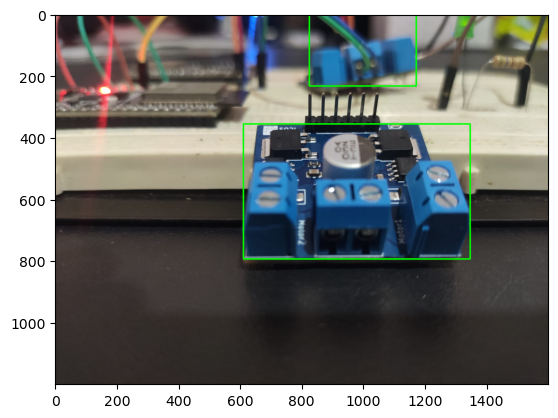

In [129]:
#El código crea una copia de una imagen, encuentra los contornos en una máscara específica y filtra aquellos que tienen un área mayor que un umbral predefinido. 
#Luego, dibuja rectángulos alrededor de los contornos grandes encontrados en la imagen copiada y muestra la imagen resultante.

img2 = Icv.copy()
contornos2, _ = cv.findContours(new_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Define un umbral de área para lo que consideras "grande"
umbral_area = 10000  

# Filtra solo los contornos grandes
contornos_grandes = [contorno for contorno in contornos2 if cv.contourArea(contorno) > umbral_area]

# Dibuja un rectángulo alrededor de cada contorno grande
for contorno in contornos_grandes:
    x, y, w, h = cv.boundingRect(contorno)
    cv.rectangle(img2, (x, y), (x + w, y + h), (0, 255, 0), 4)  

plot_show_image(img2)


## Procedememos a usar sus variables para hacer zoom y centrarlo 


In [131]:
def get_factor_zoom(img, ancho, alto):
    """
    Calcula el factor de zoom necesario para ajustar la imagen a un tamaño específico.

    Args:
        img (ndarray): La imagen a ajustar.
        ancho (int): El ancho objetivo deseado.
        alto (int): La altura objetivo deseada.

    Returns:
        float: El factor de zoom necesario para ajustar la imagen manteniendo su proporción.
    """
    # Verificar que el ancho y alto sean mayores que cero
    if ancho <= 0 or alto <= 0:
        raise ValueError("El ancho y el alto deben ser mayores que cero.")

    # Dimensiones de la imagen original
    Ht = img.shape[0]
    Wt = img.shape[1]

    # Calcular el factor de zoom
    if Ht > Wt:
        factor = Ht / alto
    else:
        factor = Wt / ancho

    return factor
   

In [132]:
def aumentar_img(img, factor):
    """
    Escala una imagen por un factor específico.

    Args:
        img (ndarray): La imagen a escalar.
        factor (float): El factor por el cual se debe escalar la imagen.
                        Debe ser mayor que 0.

    Returns:
        ndarray: La imagen escalada.
    """
    # Verificar que la imagen no sea None
    if img is None:
        raise ValueError("La imagen proporcionada es inválida.")

    # Verificar que el factor sea positivo
    if factor <= 0:
        raise ValueError("El factor de escala debe ser mayor que 0.")

    # Calcular el nuevo tamaño de la imagen
    new_size = (int(img.shape[1] * factor), int(img.shape[0] * factor))

    # Cambiar el tamaño de la imagen usando interpolación lineal
    zoomed_img = cv.resize(img, new_size, interpolation=cv.INTER_LINEAR)

    return zoomed_img

In [133]:
def centrar_y_desplazar_en_x(img,x,y,h,factor,img_org):
    """
    Desplaza una imagen en el eje X y la centra en el eje Y.

    Args:
        img (ndarray): La imagen a desplazar.
        x (float): Coordenada X inicial para el desplazamiento.
        y (float): Coordenada Y inicial para el desplazamiento.
        h (float): Altura de la región de interés.
        factor (float): Factor de escala para el desplazamiento.
        img_org (ndarray): Imagen original para referencia del centrado en Y.

    Returns:
        ndarray: La imagen desplazada y centrada.
    """
    # Validaciones básicas
    if img is None or img_org is None:
        raise ValueError("Las imágenes proporcionadas son inválidas.")
    if factor <= 0:
        raise ValueError("El factor de escala debe ser mayor que 0.")

    # Calcular la altura escalada y el centro de la región escalada
    hf = h * factor  # Altura escalada de la región
    Cnt = y * factor + hf / 2  # Centro Y de la región escalada
    yct = img_org.shape[0] / 2  # Centro Y de la imagen original

    # Calcular el desplazamiento necesario para centrar la región en Y
    dyc = yct - Cnt

    # Calcular el desplazamiento en X
    dx = -x * factor  # Desplazamiento en X, basado en la escala
    dy = dyc  # Desplazamiento en Y para centrar

    # Crear la matriz de transformación afín para el desplazamiento
    M = np.float32([[1, 0, dx], [0, 1, dy]])

    # Aplicar la transformación afín para desplazar y centrar la imagen
    shifted_img = cv.warpAffine(img, M, (img.shape[1], img.shape[0]))

    return shifted_img

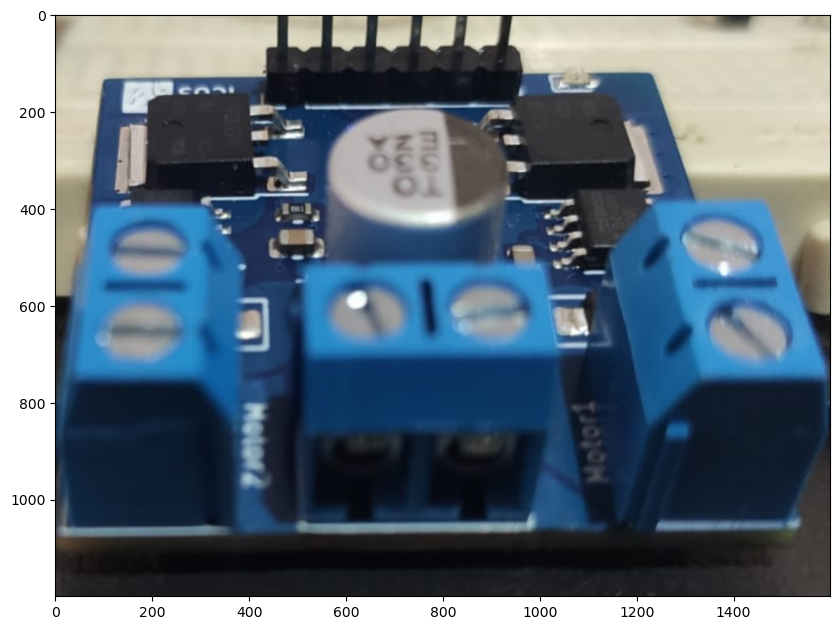

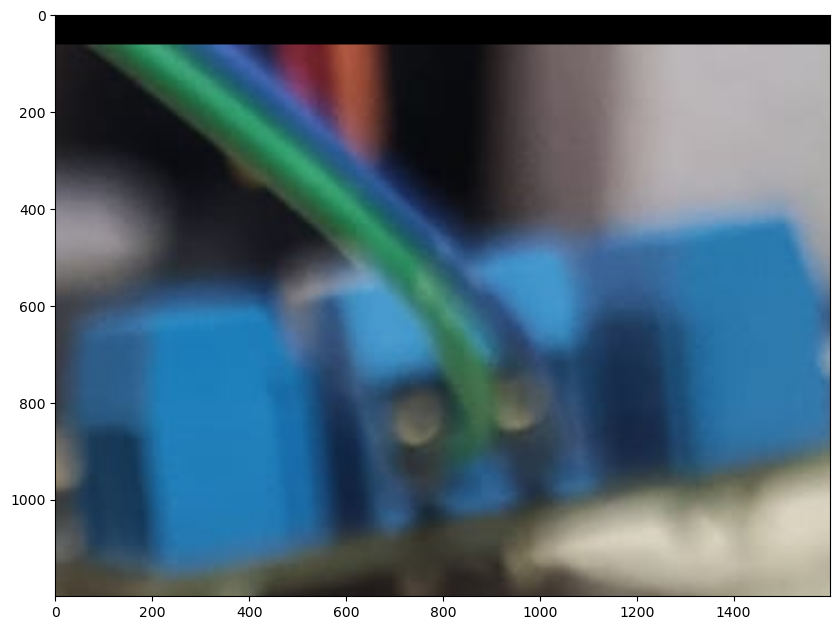

In [134]:

img = Icv.copy()
for contorno in contornos_grandes:
    x, y, w, h = cv.boundingRect(contorno)
    factor = get_factor_zoom(img, w, h)
    img_zoom = aumentar_img(img, factor)
    shifted_img = centrar_y_desplazar_en_x(img_zoom, x, y, h, factor, img)
    
    # Asegúrate de que la imagen recortada no exceda los límites de `shifted_img`
    h_cropped = min(img.shape[0], shifted_img.shape[0])
    w_cropped = min(img.shape[1], shifted_img.shape[1])
    cropped_img2 = shifted_img[0:h_cropped, 0:w_cropped]
    
    plt.figure(figsize=(10, 10))
    plt.imshow(cv.cvtColor(cropped_img2, cv.COLOR_BGR2RGB))
    plt.show()



